# Project 1: Image registration

**Contents:** <br>

- [Goal](#goal)<br>
- [Deliverables](#deliverables)<br>
- [Assessment](#assessment)<br>

- [Preliminary guided project work](#guided_work)<br>

    A. [Getting started](#getting_started)<br>
    - [Dataset](#dataset)<br>
    - [Selecting corresponding point pairs](#selecting_point_pairs)<br>
        
  B. [Point-based registration](#point-based_reg)<br>
    - [Point-based affine image registration](#affine)<br>
    - [Evaluation of point-based affine image registration](#evaluation)<br>
        
  C. [Intensity-based registration](#intensity-based_reg)<br>
    - [Comparing the results of different registration methods](#comparison)<br>

- [Open-ended project work](#open-end)

<div id="goal"></div>

<div style="float:right;margin:-5px 5px"><img src="assets/read_ico.png" width="42" height="42"></div> 


## Goal
Develop Python code for point-based and intensity-based (medical) image registration. Propose and investigate a suitable research question of your choice. Use the developed code to perform image registration and evaluate and analyze the results.

The dataset you will be using in the first project originates from the [MRBrainS medical image analysis challenge](http://mrbrains13.isi.uu.nl/). It consists of 18 traverse slices of MR brain scans with two different sequences: T1-weighted and T2-FLAIR (3 patients $\times$ 3 slices per patient $\times$ 2 modalities). Please see the [Getting started](#getting_started) assignment below for more details on the dataset.

The assignment consists of two parts, as a first step there is preliminary guided project work, and as a second step you must investigate a suitable research question based on the methods you have developed. A research question based on the preliminary guided project work below, completing the programming tasks and answering the theory questions, is the minimal solution to this project. If this is done well and accompanied by a suitable report, this will be graded with a ‘sufficient’ grade. To achieve higher grades, you need to go beyond the minimal solution. You should use what you have implemented and the available data to come up with and answer a suitable research question. Write about this in your report.

<div id="deliverables"></div>

## Deliverables
A completed version of this notebook, the documented python code that you developed, and a report describing your research question, results and analysis. The report is expected in a short, concise format. It focusses on your specific research questions, results and discussion. The lecturers already know the background, the data and the general methodology. Your report therefore does not need to include an introduction on the clinical problem nor explanations of the background of image registration. You do have to include your design choices and motivation thereof.

Aim to present your most important findings in the main body of the report and (if needed) any additional information in an appendix. The following report structure is suggested for the main body of the report:

1. Introduce research question and hypothesis with its motivation (0.5 page)
2. Study design: which data did you use, what are the requirements of your method,
why did you make certain choices. Be as complete as possible w.r.t. the components
of a study design. (0.5 page)
3. Method, experiments and results for each research question (2 pages)
4. Discussion section with analysis of the results. (1 page)
5. Contributions: a brief description by each group member of their activities in the project which can be used to to adjust individual grades to reflect a student’s (lack of) contribution to the group
6. If you use large language models (such as ChatGPT) in your course work, you are required to declare how and for what they were used and to include a reflection on the use of such tools.

The page lengths above are indications. You are free to adapt them, with the constraint of a maximum length of five pages for the first four items listed.

The report must be submitted as a single PDF file. The documented code must be submitted as a single archive file (e.g. zip or 7z) that is self-contained and can be used to reproduce the results in the report. 

Note that there is no single correct solution for the project. You have to demonstrate to the reader that you understand the methods that you have studied and can critically analyze the results of applying the methods. Below, you can find a set of assignments (guided project work) that will help you get started with the project work and, when correctly completed, will present you with a **minimal solution**. Solutions which go beyond these assignments are of course encouraged. Additionally, include the solutions to the preliminary guided project work within this notebook in the archive file. 
<div id="assessment"></div>

## Assessment
The rubric that will be used for assessment of the project work is given in [this table](https://github.com/tueimage/8BE030-MIA/blob/master/rubric.md). Please check this carefully!

In [ ]:
%load_ext autoreload
%autoreload 2

<div id='guided_work'></div>

## Preliminary guided project work

<div id="getting_started"></div>
<div style="float:right;margin:-5px 5px"><img src="assets/read_ico.png" width="42" height="42"></div> 

### A. Getting started
As an introduction, you will get familiar with the dataset that will be used in the first project and the control point selection tool that can be used to annotate corresponding points in pairs of related images. The annotated points can later be used to perform point-based registration and evaluation of the registration error.

<div id="dataset"></div>

### Dataset

The image dataset is located in the [image_data](https://github.com/tueimage/8BE030-MIA/tree/master/data/image_data) subfolder of the code for the registration exercises and project. The image filenames have the following format: `{Patient ID}_{Slice ID}_{Sequence}.tif`. For example, the filename `3_2_t1.tif` is the second slice from a T1-weighted scan of the third patient. Every T1 slice comes in two versions: original and transformed with some random transformation that can be identified with the `_d` suffix in the filename. This simulates a registration problem where you have to register two image acquisitions of the same patient (note however that some of the transformations that were used to simulate the second set of images are not realistic for brain imaging, e.g. brain scans typically do not encounter shearing between consecutive acquisitions).

<div style="float:right;margin:-5px 5px"><img src="assets/question_ico.png" width="42" height="42"></div> 

### *Question 1*:

With this dataset we can define two image registration problems: T1 to T1 registration (e.g. register `3_2_t1_d.tif` to `3_2_t1.tif`) and T2 to T1 registration (e.g. register `3_2_t2.tif` to `3_2_t1.tif`). Which one of these can be considered inter-modal image registration and which one intra-modal image registration?

T1 to T1 registration is intra-modal image registration, because both images come from the same imaging modality/sequence. In the example, 3_2_t1_d.tif is a transformed version of the original T1 image 3_2_t1.tif.

T2 to T1 registration is inter-modal image registgit add reader/1.6_Registration_project.ipynbration, because the images come from different MRI sequences. For example, 3_2_t2.tif is a T2-FLAIR image, while 3_2_t1.tif is a T1-weighted image.

<div id="selecting_point_pairs"></div>

### Selecting corresponding point pairs

A function called `cpselect` is provided to select control points in two different images. This function provides two numpy arrays of cartesian coordinates, one array for each image, of points selected in the two images. The coordinate format is a numpy array with the X and Y on row 0 and 1 respectively, and each column being a point.

Calling the function will cause a new interactive window to pop up, where you will see your two images and some instructions.
For convenience, the instructions can also be found below:

* First select a point in Image 1 and then its corresponding point in Image 2. This pattern should be repeated for as many control points as you need. If you do not follow this pattern, the output arrays will be incorrect.
* Left Mouse Button to create a point. 
* Right Mouse Button/Delete/Backspace to remove the newest point. 
* Middle Mouse Button/Enter to finish placing points. 

<div style="float:right;margin:-5px 5px"><img src="assets/todo_ico.png" width="42" height="42"></div> 

### *Task 1*:

Test the functionality of `cpselect` by running the following code example:

In [ ]:
import sys
sys.path.append("../code")
import registration_util as util

I_path = '../data/image_data/1_1_t1.tif'
Im_path = '../data/image_data/1_1_t1_d.tif'

X, Xm = util.cpselect(I_path, Im_path)

print('X:\n{}'.format(X))
print('Xm:\n{}'.format(Xm))

<div id="point-based_reg"></div>

## B. Point-based registration

<div style="float:right;margin:-5px 5px"><img src="assets/todo_ico.png" width="42" height="42"></div> 

<div id="affine"></div>

### Point-based affine image registration

From the provided dataset for this project, select one pair of T1 image slices (e.g. `3_2_t1.tif` and `3_2_t1_d.tif`) and use `my_cpselect` to select a set of corresponding points. Then, compute the affine transformation between the pair of images with `ls_affine` and apply it to the moving image using `image_transform`. 

Repeat the same for a pair of corresponding T1 and T2 slices (e.g. `3_2_t1.tif` and `3_2_t2.tif`).

In [ ]:
import os
import sys
sys.path.append("code")

import registration_util as util
from registration import *
from matplotlib import pyplot as plt

print(os.getcwd())

T1_path = '../data/image_data/2_1_t1.tif'
Tm1_path = '../data/image_data/2_1_t1_d.tif'
T2_path = '../data/image_data/2_1_t2.tif'

moving_image = plt.imread(Tm1_path)
original_image = plt.imread(T1_path)
T2_image = plt.imread(T2_path)

T1, Tm1 = util.my_cpselect(T1_path, Tm1_path)


In [ ]:
print(f"T : {T1}\nTm : {Tm1}")

In [ ]:
transformation_matrix = ls_affine(T1, Tm1)
print('Transformation matrix:\n{}'.format(transformation_matrix))

resulted_image, xc = image_transform(moving_image, transformation_matrix)

# transformed_image = plt.imread(resulted_image)

# Visualize the images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(moving_image)
axes[0].set_title('Moving Image')
axes[0].axis('off')

axes[1].imshow(original_image)
axes[1].set_title('Original Image')
axes[1].axis('off')

axes[2].imshow(resulted_image)
axes[2].set_title('Transformed Image')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
T1, T2 = util.my_cpselect(T1_path, T2_path)
print(f"T : {T1}\nTm : {Tm1}")

In [ ]:
transformation_matrix_T2 = ls_affine(T1, T2)
print('Transformation matrix:\n{}'.format(transformation_matrix_T2))

resulted_image_T2, xc = image_transform(T2_image, transformation_matrix_T2)

# transformed_image = plt.imread(resulted_image)

# Visualize the images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(T2_image)
axes[0].set_title('T2 Image')
axes[0].axis('off')

axes[1].imshow(original_image)
axes[1].set_title('Original Image')
axes[1].axis('off')

axes[2].imshow(resulted_image_T2)
axes[2].set_title('Transformed Image')
axes[2].axis('off')

plt.tight_layout()
plt.show()

<div id="evaluation"></div>

### Evaluation of point-based affine image registration

<div style="float:right;margin:-5px 5px"><img src="assets/question_ico.png" width="42" height="42"></div> 

### *Question 2*:
Describe how you would estimate the registration error. (Hint: Should you use the same points that you used for computing the affine transformation to also compute the registration error?) How does the number of corresponding point pairs affect the registration error? Motivate all your answers.

In [ ]:
""" The registration error can be estimated by applying the computed affine transformation to the moving-image control points and then measuring the Euclidean distance between the 
transformed points and their corresponding points in the fixed image, typically summarized using the mean error or RMSE. The same points used to compute the affine transformation
should generally not be used to estimate the registration error, since the transformation was optimized specifically for those points, which would lead to an overly optimistic and 
biased error estimate. Instead, a separate set of validation points should be used to evaluate how well the registration generalizes to unseen locations. The number of corresponding
point pairs also affects the registration accuracy: using only the minimum number of points required for an affine transformation makes the solution sensitive to noise and point-selection
inaccuracies, while using more accurate point pairs generally improves robustness and reduces the registration error because the transformation is estimated from more information.
However, adding incorrect or poorly selected correspondences can increase the error and worsen the registration result."""

<div id="intensity-based_reg"></div>

## C. Intensity-based registration

<div style="float:right;margin:-5px 5px"><img src="assets/todo_ico.png" width="42" height="42"></div> 

<div id="comparison"></div>

### Comparing the results of different registration methods

The following Python script (provided as `intensity_based_registration_demo()`) performs rigid intensity-based registration of two images using the normalized-cross correlation as a similarity metric:

In [ ]:
%matplotlib inline
import sys
import os

sys.path.append("../code")
from registration_project import intensity_based_registration_demo
print(os.getcwd())

intensity_based_registration_demo()

<div style="float:right;margin:-5px 5px"><img src="assets/todo_ico.png" width="42" height="42"></div> 

### *Task 2*:

By changing the similarity function and the initial parameter vector, you can also use this script to perform affine registration and use mutual information as a similarity measure. Do not forget to also change the transformation for the visualization of the results.

Using the provided dataset and the functions that you have implemented in the exercises, perform the following series of experiments:

1. Rigid intensity-based registration of two T1 slices (e.g. `1_1_t1.tif` and `1_1_t1_d.tif`) using normalized cross-correlation as a similarity measure.
2. Affine intensity-based registration of two T1 slices (e.g. `1_1_t1.tif` and `1_1_t1_d.tif`) using normalized cross-correlation as a similarity measure.
3. Affine intensity-based registration of a T1 and a T2 slice (e.g. `1_1_t1.tif` and `1_1_t2.tif`) using normalized cross-correlation as a similarity measure.
4. Affine intensity-based registration of two T1 slices (e.g. `1_1_t1.tif` and `1_1_t1_d.tif`) using mutual information as a similarity measure.
5. Affine intensity-based registration of a T1 slice and a T2 slice (e.g. `1_1_t1.tif` and `1_1_t2.tif`) using mutual information as a similarity measure.

Compare the results from each experiment. If a method fails, describe why you think it fails. Note that you will most likely have to try different values for the learning rate in each experiment in order to find the one that works best. 

In [ ]:
import sys
import matplotlib.pyplot as plt

sys.path.append("../code")

from registration_project import intensity_based_registration

im_1_1_t1 = plt.imread('../data/image_data/1_1_t1.tif')
im_1_1_t1_d = plt.imread('../data/image_data/1_1_t1_d.tif')
im_1_1_t2 = plt.imread('../data/image_data/1_1_t2.tif')
import os 
print(os.getcwd())


In [ ]:
intensity_based_registration(im_1_1_t1, im_1_1_t1_d, method = 'rigid_cc', num_iter = 200, mu = 0.001)

In [ ]:
intensity_based_registration(im_1_1_t1, im_1_1_t1_d, method='affine_cc', num_iter= 200, mu = 0.001)

In [ ]:
intensity_based_registration(im_1_1_t1, im_1_1_t2, method='affine_cc', num_iter= 200, mu = 0.001)

In [ ]:
intensity_based_registration(im_1_1_t1, im_1_1_t2, method='affine_mi', num_iter= 200, mu = 0.0005)

<div id="open-end"></div>

<div style="float:right;margin:-5px 5px"><img src="assets/todo_ico.png" width="42" height="42"></div> 


## Open-ended project work

Define and motivate one research question that you will investigate. This can be a question relating to a method (e.g. what is the impact of X on a particular method) or relating to the problem (e.g. does a specific method fail in specific cases). 
It is recommended to get feedback on your research question from the teaching assistants.

#### Project setup: noise levels for affine inter-modal registration

For our research question, we use one selected patient and study how added image noise affects affine intensity-based registration between a fixed T1-weighted image and a moving T2/T2-FLAIR image. The registration step will use affine transformation parameters and mutual information later on. First, we prepare the three moving-image noise conditions: no added noise, low noise, and higher noise.


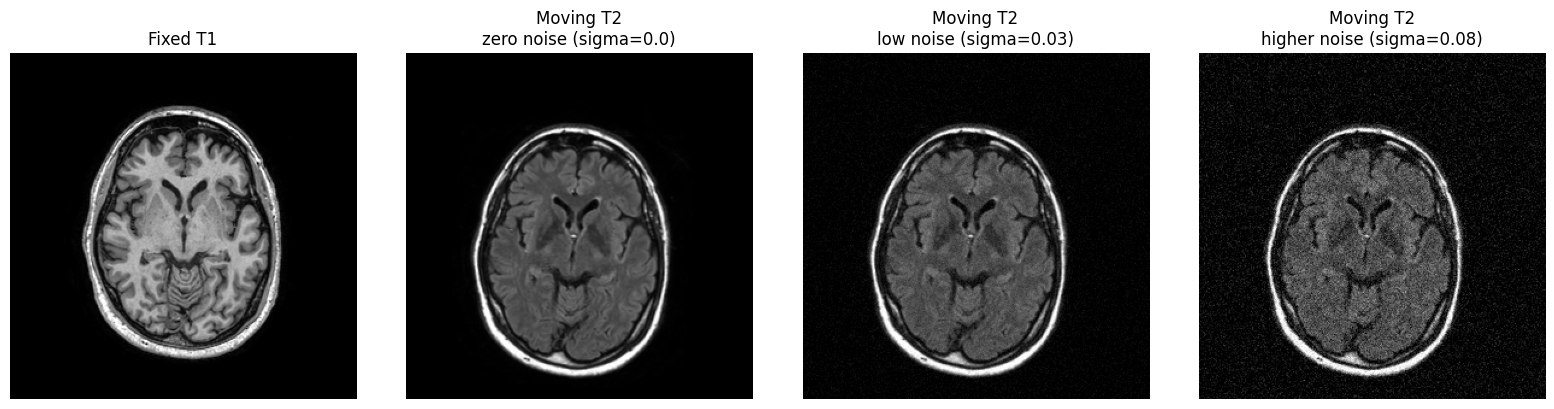

zero noise: sigma=0.00, min=0.000, max=1.000, mean=0.106
low noise: sigma=0.03, min=0.000, max=1.000, mean=0.114
higher noise: sigma=0.08, min=0.000, max=1.000, mean=0.127


In [ ]:
# TO BE REPLACED CODE EMERY

import sys
sys.path.append("../code")

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# this cell prepares the image data for our research question.
# keep the T1 image fixed, and later  register the noisy T2 image to it.
# lets us test whether added noise makes affine intensity-based registration worse.
data_dir = Path("../data/image_data")
if not data_dir.exists():
    data_dir = Path("data/image_data")

# use one patient and one slice throughout the open ended project work
# T1 image is the fixed/reference image, T2 image is the moving image
fixed_t1_path = data_dir / "1_1_t1.tif"
moving_t2_path = data_dir / "1_1_t2.tif"

def normalize_image(image):
    # convert the image to floating point values and rescale it to [0, 1].
    # This makes the noise levels easier to interpret, because sigma is then
    # expressed relative to the same intensity range for every image.
    image = image.astype(float)
    image_range = image.max() - image.min()
    if image_range == 0:
        return np.zeros_like(image)
    return (image - image.min()) / image_range

def add_gaussian_noise(image, sigma, rng):
    # add zero-mean Gaussian noise to the moving image.
    # sigma controls the strength of the noise: if sigma is zero, then no noise is added
    # larger sigma values make the image progressively noisier. we opted to go with three levels, zero noise, and then two levels of noise higher. 
    if sigma == 0:
        return image.copy()
    noisy_image = image + rng.normal(loc=0.0, scale=sigma, size=image.shape)
    return np.clip(noisy_image, 0.0, 1.0)

# load and normalize the images before adding noise.
# I_fixed stays the same for every experiment; only I_moving changes through noise.
I_fixed = normalize_image(plt.imread(fixed_t1_path))
I_moving = normalize_image(plt.imread(moving_t2_path))

# 3 noise conditions for the RQ: baseline, mild noise, and stronger noise as said earlier
# the images will be used later as input for affine registration with mutual information.
noise_levels = {
    "zero noise": 0.00,
    "low noise": 0.03,
    "higher noise": 0.08,
}

# fixed random seed so the exact same noisy images are generated each time.
rng = np.random.default_rng(42)
I_moving_noisy = {
    label: add_gaussian_noise(I_moving, sigma, rng)
    for label, sigma in noise_levels.items()
}

# visual check here, the fixed T1 image is shown next to the three moving T2 versions.
# useful before registration, because we can confirm that only the moving image is being changed by the noise experiment.
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(I_fixed, cmap="gray")
axes[0].set_title("Fixed T1")
axes[0].axis("off")

for ax, (label, sigma) in zip(axes[1:], noise_levels.items()):
    ax.imshow(I_moving_noisy[label], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Moving T2\n{label} (sigma={sigma})")
    ax.axis("off")

plt.tight_layout()
plt.show()

# print simple summary values so we can quickly check that the noise was applied.
# zero noise image should match the normalized moving image, while noisy images should still remain within the [0, 1] range because of clipping.
for label, image in I_moving_noisy.items():
    print(
        f"{label}: sigma={noise_levels[label]:.2f}, "
        f"min={image.min():.3f}, max={image.max():.3f}, mean={image.mean():.3f}"
    )


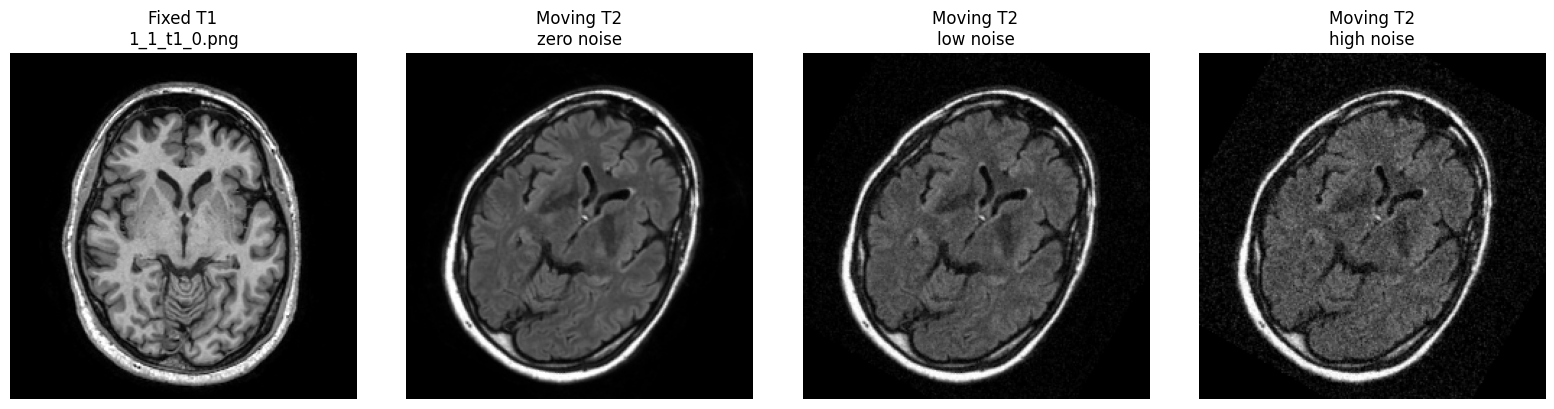

running affine MI registration for zero noise
  final similarity: 0.6521
running affine MI registration for low noise
  final similarity: 0.5900
running affine MI registration for high noise
  final similarity: 0.5615


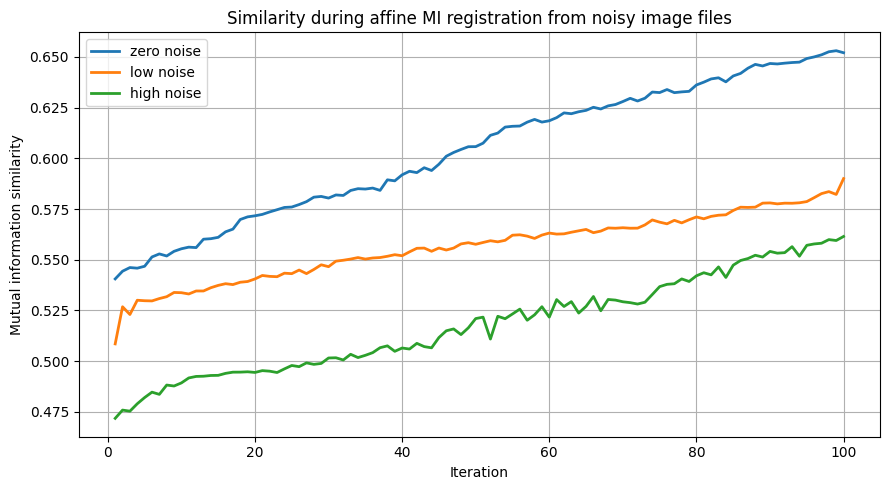

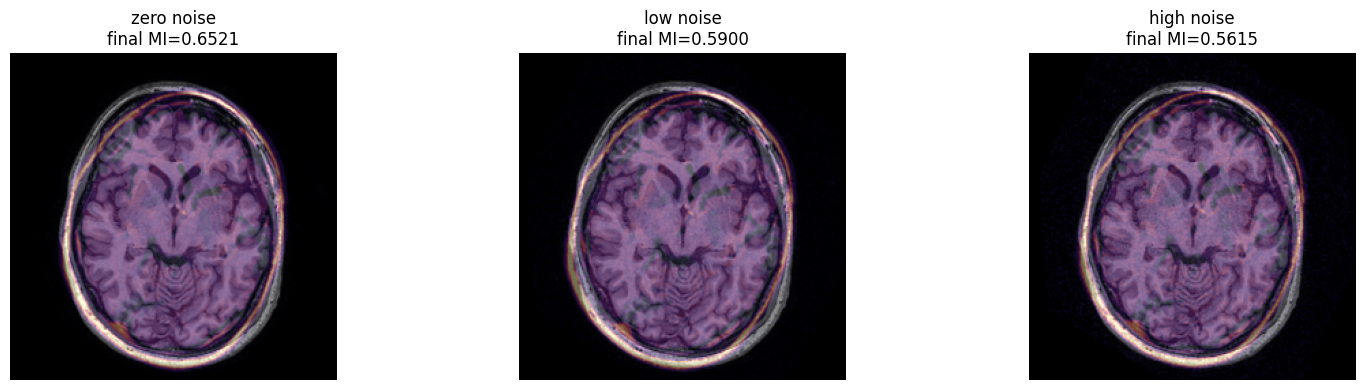

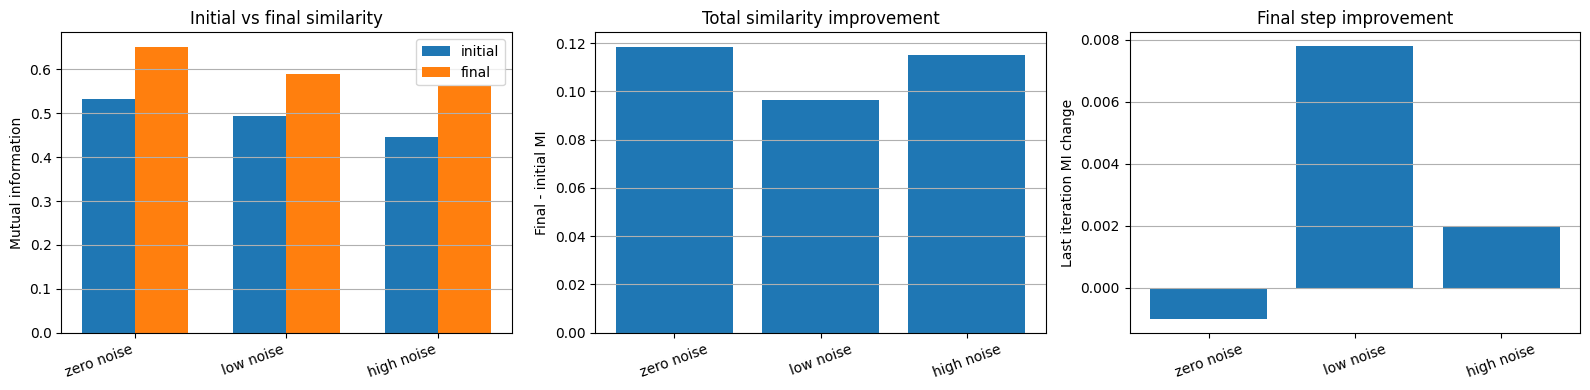

summary metrics
noise label      initial MI   final MI   improvement   final step   iterations
zero noise          0.5335     0.6521       0.1186  -0.001002        100
low noise           0.4937     0.5900       0.0963   0.007802        100
high noise          0.4466     0.5615       0.1149   0.001992        100


In [3]:
import sys
sys.path.append("../code")

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import registration as reg
import registration_util as util

# Use the already-created noisy image files from data/noisy_image_data.
# Keep the T1 image fixed and register the three T2 noise conditions to it.
noisy_data_dir = Path("../data/noisy_image_data")
if not noisy_data_dir.exists():
    noisy_data_dir = Path("data/noisy_image_data")

fixed_t1_noisy_path = noisy_data_dir / "1_1_t1_0.png"
moving_t2_noisy_paths = {
    "zero noise": noisy_data_dir / "1_1_t2_0.png",
    "low noise": noisy_data_dir / "1_1_t2_1.png",
    "high noise": noisy_data_dir / "1_1_t2_2.png",
}


def normalize_image(image):
    image = image.astype(float)
    if image.ndim == 3:
        image = image[..., :3].mean(axis=2)
    image_range = image.max() - image.min()
    if image_range == 0:
        return np.zeros_like(image)
    return (image - image.min()) / image_range


I_fixed_file = normalize_image(plt.imread(fixed_t1_noisy_path))
I_moving_noisy_files = {
    label: normalize_image(plt.imread(path))
    for label, path in moving_t2_noisy_paths.items()
}

# Visual check of the exact image files used in this experiment.
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(I_fixed_file, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Fixed T1\n1_1_t1_0.png")
axes[0].axis("off")

for ax, (label, image) in zip(axes[1:], I_moving_noisy_files.items()):
    ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Moving T2\n{label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

num_iter = 100
learning_rate = 0.001
SCALING = 100
initial_affine_parameters = np.array([0., 1., 1., 0., 0., 0., 0.])


def affine_mi_registration_with_history(I, Im, num_iter=100, mu=0.001):
    # Same affine mutual-information setup as intensity_based_registration(),
    # but this version returns the full iteration history so we can compare noise levels.
    x = initial_affine_parameters.copy()
    fun = lambda params: reg.affine_mi(I, Im, params, return_transform=False)

    initial_similarity = fun(x)
    similarity_history = np.full(num_iter, np.nan)
    parameter_history = np.full((num_iter, len(x)), np.nan)

    for k in range(num_iter):
        gradient = reg.ngradient(fun, x)
        x = x + gradient * mu

        similarity_history[k] = fun(x)
        parameter_history[k] = x.copy()

    T = reg.rotate(x[0]).dot(reg.scale(x[1], x[2])).dot(reg.shear(x[3], x[4]))
    Th = util.t2h(T, x[5:] * SCALING)
    transformed_image, _ = reg.image_transform(Im, Th)

    valid_similarity = similarity_history[~np.isnan(similarity_history)]
    final_similarity = valid_similarity[-1]
    previous_similarity = valid_similarity[-2] if len(valid_similarity) > 1 else initial_similarity

    return {
        "initial_similarity": initial_similarity,
        "final_similarity": final_similarity,
        "similarity_improvement": final_similarity - initial_similarity,
        "final_step_improvement": final_similarity - previous_similarity,
        "iterations": len(valid_similarity),
        "similarity_history": similarity_history,
        "parameter_history": parameter_history,
        "final_parameters": x,
        "transformed_image": transformed_image,
        "transform_matrix": Th,
    }


registration_results_from_files = {}
for label, moving_image in I_moving_noisy_files.items():
    print(f"running affine MI registration for {label}")
    registration_results_from_files[label] = affine_mi_registration_with_history(
        I_fixed_file,
        moving_image,
        num_iter=num_iter,
        mu=learning_rate,
    )
    print(f"  final similarity: {registration_results_from_files[label]['final_similarity']:.4f}")

# Plot the similarity at every iteration for all three noise labels in one figure.
fig, ax = plt.subplots(figsize=(9, 5))
iterations = np.arange(1, num_iter + 1)
for label, result in registration_results_from_files.items():
    ax.plot(iterations, result["similarity_history"], lw=2, label=label)
ax.set_xlabel("Iteration")
ax.set_ylabel("Mutual information similarity")
ax.set_title("Similarity during affine MI registration from noisy image files")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# Show final registered overlays for zero, low, and high noise.
fig, axes = plt.subplots(1, len(registration_results_from_files), figsize=(16, 4))
for ax, (label, result) in zip(axes, registration_results_from_files.items()):
    ax.imshow(I_fixed_file, cmap="gray")
    ax.imshow(result["transformed_image"], cmap="magma", alpha=0.45)
    ax.set_title(
        f"{label}\n"
        f"final MI={result['final_similarity']:.4f}"
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

# Plot compact summary metrics for the research question.
labels = list(registration_results_from_files.keys())
x_pos = np.arange(len(labels))
initial_values = [registration_results_from_files[label]["initial_similarity"] for label in labels]
final_values = [registration_results_from_files[label]["final_similarity"] for label in labels]
improvements = [registration_results_from_files[label]["similarity_improvement"] for label in labels]
final_step_improvements = [registration_results_from_files[label]["final_step_improvement"] for label in labels]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
width = 0.35
axes[0].bar(x_pos - width / 2, initial_values, width, label="initial")
axes[0].bar(x_pos + width / 2, final_values, width, label="final")
axes[0].set_title("Initial vs final similarity")
axes[0].set_ylabel("Mutual information")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(labels, rotation=20, ha="right")
axes[0].legend()
axes[0].grid(axis="y")

axes[1].bar(labels, improvements)
axes[1].set_title("Total similarity improvement")
axes[1].set_ylabel("Final - initial MI")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y")

axes[2].bar(labels, final_step_improvements)
axes[2].set_title("Final step improvement")
axes[2].set_ylabel("Last iteration MI change")
axes[2].tick_params(axis="x", rotation=20)
axes[2].grid(axis="y")

plt.tight_layout()
plt.show()

print("summary metrics")
print("noise label      initial MI   final MI   improvement   final step   iterations")
for label in labels:
    result = registration_results_from_files[label]
    print(
        f"{label:<14} "
        f"{result['initial_similarity']:>11.4f} "
        f"{result['final_similarity']:>10.4f} "
        f"{result['similarity_improvement']:>12.4f} "
        f"{result['final_step_improvement']:>10.6f} "
        f"{result['iterations']:>10}"
    )


In [5]:
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt

# Save outputs inside the project data folder
output_dir = Path("/Users/larsheijnen/uni_projects/medical_image_analysis_project/8BE030-MIA/data/registration_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

# These are the original moving T2 images used for each noise condition.
moving_t2_noisy_paths = {
    "zero noise": noisy_data_dir / "1_1_t2_0.png",
    "low noise": noisy_data_dir / "1_1_t2_1.png",
    "high noise": noisy_data_dir / "1_1_t2_2.png",
}

def safe_label(label):
    return label.replace(" ", "_")

summary_rows = []

for label, moving_path in moving_t2_noisy_paths.items():
    result = registration_results_from_files[label]

    final_parameters = result["final_parameters"]
    transform_matrix = result["transform_matrix"]

    # Re-load the related original T2 image and apply its transform
    moving_t2_image = normalize_image(plt.imread(moving_path))
    aligned_t2_image, _ = reg.image_transform(moving_t2_image, transform_matrix)

    name = safe_label(label)

    vector_csv_path = output_dir / f"{name}_final_parameters.csv"
    with open(vector_csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "rotation",
            "scale_x",
            "scale_y",
            "shear_x",
            "shear_y",
            "translation_x_scaled",
            "translation_y_scaled",
        ])
        writer.writerow(final_parameters)

    vector_txt_path = output_dir / f"{name}_final_parameters.txt"
    with open(vector_txt_path, "w") as f:
        f.write(f"Noise label: {label}\n")
        f.write("Final affine parameter vector:\n")
        f.write(np.array2string(final_parameters, precision=8, separator=", "))
        f.write("\n\n")
        f.write("Parameter order:\n")
        f.write(
            "rotation, scale_x, scale_y, shear_x, shear_y, "
            "translation_x_scaled, translation_y_scaled\n"
        )

    matrix_csv_path = output_dir / f"{name}_transform_matrix.csv"
    with open(matrix_csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["m00", "m01", "m02"])
        writer.writerow(transform_matrix[0])
        writer.writerow(transform_matrix[1])
        writer.writerow(transform_matrix[2])

    matrix_txt_path = output_dir / f"{name}_transform_matrix.txt"
    with open(matrix_txt_path, "w") as f:
        f.write(f"Noise label: {label}\n")
        f.write("Homogeneous transformation matrix:\n")
        f.write(np.array2string(transform_matrix, precision=8, separator=", "))
        f.write("\n")

    aligned_image_path = output_dir / f"{name}_aligned_t2.png"
    plt.imsave(aligned_image_path, aligned_t2_image, cmap="gray", vmin=0, vmax=1)

    summary_rows.append({
        "noise_label": label,
        "final_parameters_csv": vector_csv_path.name,
        "final_parameters_txt": vector_txt_path.name,
        "transform_matrix_csv": matrix_csv_path.name,
        "transform_matrix_txt": matrix_txt_path.name,
        "aligned_t2_png": aligned_image_path.name,
    })

summary_csv_path = output_dir / "saved_registration_outputs_summary.csv"
with open(summary_csv_path, "w", newline="") as f:
    fieldnames = [
        "noise_label",
        "final_parameters_csv",
        "final_parameters_txt",
        "transform_matrix_csv",
        "transform_matrix_txt",
        "aligned_t2_png",
    ]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(summary_rows)

print(f"Saved registration outputs to: {output_dir}")
for row in summary_rows:
    print(row)

Saved registration outputs to: /Users/larsheijnen/uni_projects/medical_image_analysis_project/8BE030-MIA/data/registration_outputs
{'noise_label': 'zero noise', 'final_parameters_csv': 'zero_noise_final_parameters.csv', 'final_parameters_txt': 'zero_noise_final_parameters.txt', 'transform_matrix_csv': 'zero_noise_transform_matrix.csv', 'transform_matrix_txt': 'zero_noise_transform_matrix.txt', 'aligned_t2_png': 'zero_noise_aligned_t2.png'}
{'noise_label': 'low noise', 'final_parameters_csv': 'low_noise_final_parameters.csv', 'final_parameters_txt': 'low_noise_final_parameters.txt', 'transform_matrix_csv': 'low_noise_transform_matrix.csv', 'transform_matrix_txt': 'low_noise_transform_matrix.txt', 'aligned_t2_png': 'low_noise_aligned_t2.png'}
{'noise_label': 'high noise', 'final_parameters_csv': 'high_noise_final_parameters.csv', 'final_parameters_txt': 'high_noise_final_parameters.txt', 'transform_matrix_csv': 'high_noise_transform_matrix.csv', 'transform_matrix_txt': 'high_noise_transf